### Замер времени выполения

In [1]:
import time
start_time = time.perf_counter()

### Подключаем основные модули

In [2]:
from pathlib import Path

from chdb import datastore as ds
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

import my_modules.my_modules as mm

Default dirty pages decay period: 5000ms


In [3]:
%matplotlib inline

### Подключаемся к база данных `clickhouse`

При использовании модуля `chdb` можно работать без подключения к базе (см. notebook `cars2_file.ipynb`).

Работа с файлом примерно в `2` раза медленнее, нежели работа с базой.

In [4]:
%%time
dsf = ds.DataStore.from_clickhouse(
    host='service.db_clickhouse',
    port=9000,
    database='cars',
    # table='car_sales',
    # user='default',
    password=''
)

CPU times: user 180 µs, sys: 11 µs, total: 191 µs
Wall time: 203 µs


### Получение описательной статистики

In [5]:
%%time
dsf["car_sales"].describe()

CPU times: user 303 ms, sys: 134 ms, total: 438 ms
Wall time: 640 ms


,year,mileage,power,price,engineDisplacement
count,724644.000000,771799.000000,1.273353e+06,1.294757e+06,717625.000000
mean,2009.684535,154893.397115,1.415560e+02,1.444358e+06,1.950863
std,9.367108,100738.336936,6.563943e+01,1.970257e+06,0.755930
min,1936.000000,1000.000000,1.000000e+00,2.700000e+02,0.500000
25%,2003.000000,82000.000000,9.800000e+01,4.250000e+05,1.500000
50%,2011.000000,144000.000000,1.280000e+02,8.700000e+05,1.700000
75%,2017.000000,211000.000000,1.630000e+02,1.765000e+06,2.000000
max,2023.000000,1000000.000000,1.000000e+03,1.500000e+08,8.400000


In [6]:
%%time
dsf_info = dsf["car_sales"].info()
dsf_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294757 entries, 0 to 1294756
Data columns (total 18 columns):
  #   Column                Non-Null Count    Dtype  
 --  --------------------  ----------------  -----  
  0   brand                 1294757 non-null  object
  1   name                  1294757 non-null  object
  2   bodyType              1294757 non-null  object
  3   color                 1257029 non-null  object
  4   fuelType              1289815 non-null  object
  5   year                  724644 non-null   uint32
  6   mileage               771799 non-null   uint32
  7   transmission          1289563 non-null  object
  8   power                 1273353 non-null  uint16
  9   price                 1294757 non-null  uint32
 10   vehicleConfiguration  724647 non-null   object
 11   engineName            720976 non-null   object
 12   engineDisplacement    717625 non-null   float64
 13   date                  1294757 non-null  datetime64[s]
 14   location              12

In [7]:
%%time
total_rows, total_null_val, types, table = mm.custom_info(dsf["car_sales"])
with pd.option_context(
    'display.expand_frame_repr', False,
):
    display(table)
    print(f"Всего записей: {total_rows}, Null значений: {total_null_val}, Типы данных: {types}")

,Column,Non-Null Count,Non-Null Count %,Null Count,Null Count %,Total Rows,Dtype
0,brand,1294757,100.000000,0,0.000000,1294757,object
1,name,1294757,100.000000,0,0.000000,1294757,object
2,bodyType,1294757,100.000000,0,0.000000,1294757,object
3,color,1257029,97.090000,37728,2.910000,1294757,object
4,fuelType,1289815,99.620000,4942,0.380000,1294757,object
5,year,724644,55.970000,570113,44.030000,1294757,uint32
6,mileage,771799,59.610000,522958,40.390000,1294757,uint32
7,transmission,1289563,99.600000,5194,0.400000,1294757,object
8,power,1273353,98.350000,21404,1.650000,1294757,uint16
9,price,1294757,100.000000,0,0.000000,1294757,uint32


Всего записей: 1294757, Null значений: 2923714, Типы данных: datetime64[s](2), float64(1), object(11), uint16(1), uint32(3)
CPU times: user 115 ms, sys: 16.9 ms, total: 132 ms
Wall time: 838 ms


In [8]:
%%time

cl = dsf["car_sales"].columns.to_list()
cl.remove("link")
cl.remove("description")

dfs = []
sample_size_per_group = 10000

for group_id in range(1, 4):
    query = f"""
    WITH ranked AS (
        SELECT {','.join(cl)}, NTILE(3) OVER (ORDER BY rand()) AS tile
        FROM cars.car_sales
    )
    SELECT * FROM ranked
    WHERE tile = {group_id}
    ORDER BY rand()
    LIMIT {sample_size_per_group}
    """
    
    dfs.append(dsf.sql(query))

CPU times: user 824 ms, sys: 428 ms, total: 1.25 s
Wall time: 4.19 s


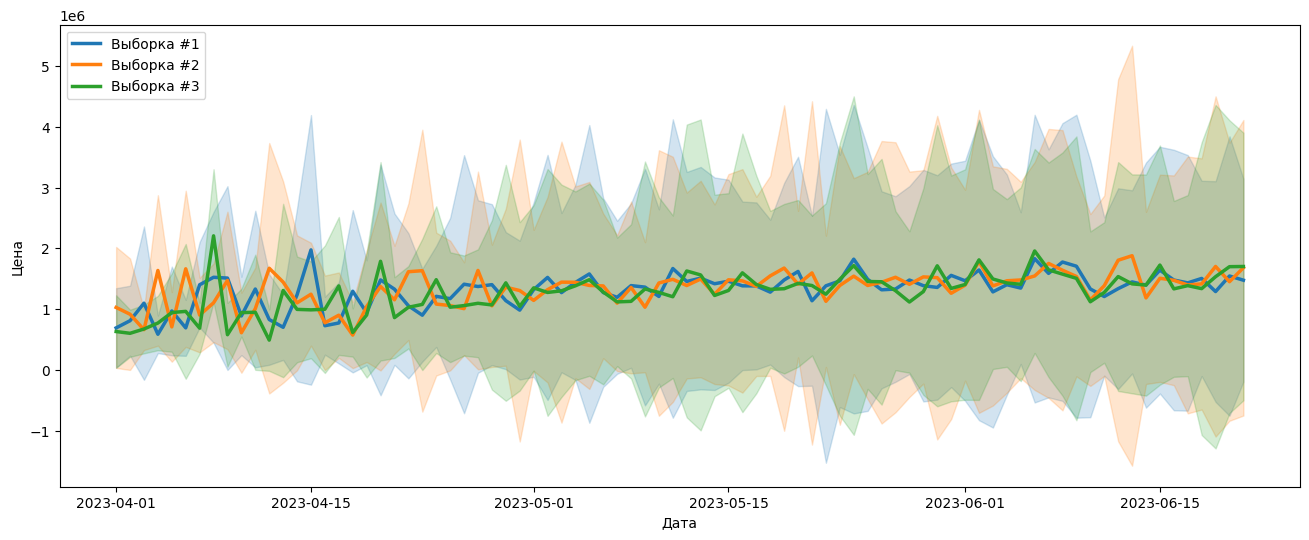

CPU times: user 744 ms, sys: 20.2 ms, total: 765 ms
Wall time: 781 ms


In [9]:
%%time
plt.figure(figsize=(16, 6))
for idx, df_number in enumerate(dfs, 1):
    sns.lineplot(x='date', y='price', data=df_number, linewidth=2.5, errorbar='sd', label=f"Выборка #{idx}")
plt.xlabel('Дата') 
plt.ylabel('Цена') 
plt.show()

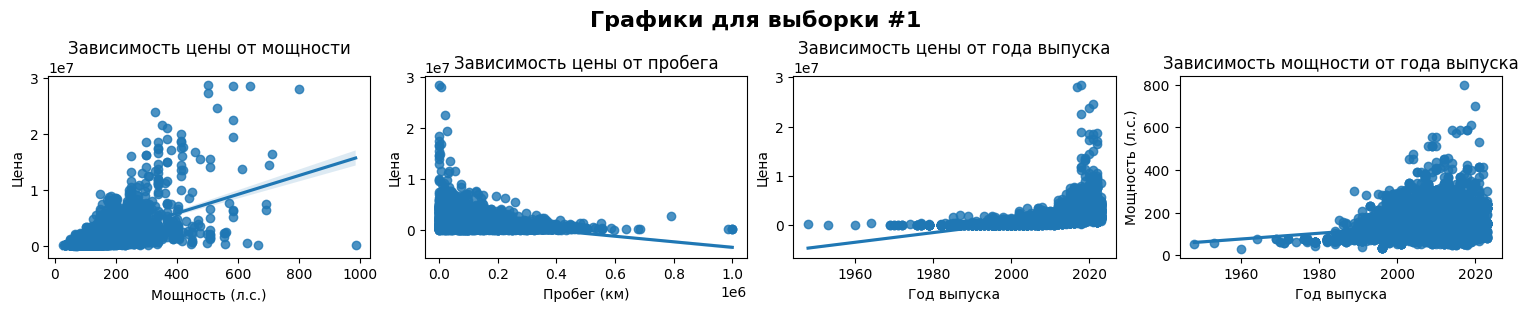

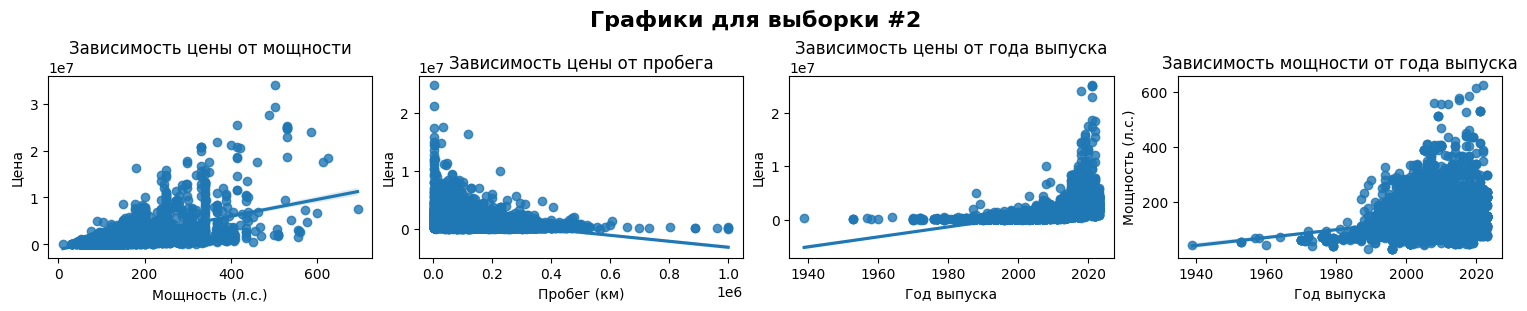

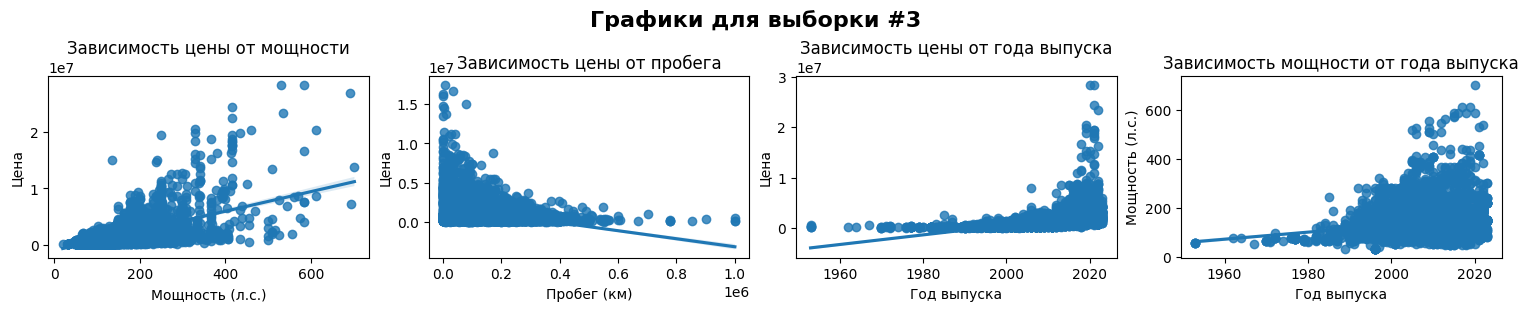

CPU times: user 4.23 s, sys: 32 ms, total: 4.27 s
Wall time: 4.23 s


In [10]:
%%time

for idx, df_number in enumerate(dfs):
    fig, axes = plt.subplots(1, 4, figsize=(15, 3), constrained_layout=True)
    fig.suptitle(f'Графики для выборки #{idx + 1}', fontsize=16, fontweight='bold')

    # График 1: power vs price
    sns.regplot(data=dfs[idx], x='power', y='price', ax=axes[0])
    axes[0].set_xlabel('Мощность (л.с.)')
    axes[0].set_ylabel('Цена')
    axes[0].set_title('Зависимость цены от мощности')

    # График 2: mileage vs price
    sns.regplot(data=dfs[idx], x='mileage', y='price', ax=axes[1])
    axes[1].set_xlabel('Пробег (км)')
    axes[1].set_ylabel('Цена')
    axes[1].set_title('Зависимость цены от пробега')

    # График 3: year vs price
    sns.regplot(data=dfs[idx], x='year', y='price', ax=axes[2])
    axes[2].set_xlabel('Год выпуска')
    axes[2].set_ylabel('Цена')
    axes[2].set_title('Зависимость цены от года выпуска')

    # График 4: year vs power
    sns.regplot(data=dfs[idx], x='year', y='power', ax=axes[3])
    axes[3].set_xlabel('Год выпуска')
    axes[3].set_ylabel('Мощность (л.с.)')
    axes[3].set_title('Зависимость мощности от года выпуска')

plt.show()


In [11]:
end_time = time.perf_counter()
total_time = end_time - start_time
print(f"Общее время выполнения: {total_time:.4f} секунд")

Общее время выполнения: 13.4777 секунд
